In [3]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

In [4]:
# Задание 1
con = sqlite3.connect('northwind.db')
df = pd.read_sql("""
 WITH revenues AS (
 SELECT shipregion, customerid, orders.orderid, orderdate, productid,
 (unitprice * quantity * (1 - discount)) AS revenue
 FROM orders
 JOIN "order details" ON orders.orderid = "order details".orderid
 )
 SELECT orderdate, shipregion, customerid, SUM(revenue) AS revenuedaily, COUNT(orderid)
AS ordersdaily
 FROM revenues
 GROUP BY orderdate
""", con=con, parse_dates=['orderdate'])
df['orderdate'] = pd.to_datetime(df['orderdate'])
display(df.info())
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15932 entries, 0 to 15931
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   orderdate     15452 non-null  datetime64[ns]
 1   shipregion    15932 non-null  object        
 2   customerid    15932 non-null  object        
 3   revenuedaily  15932 non-null  float64       
 4   ordersdaily   15932 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 622.5+ KB


None

,orderdate,shipregion,customerid,revenuedaily,ordersdaily
0,2012-07-10 15:40:46,Western Europe,GREAL,28992.85,41
1,2012-07-10 20:28:57,North America,RICAR,24589.35,47
2,2012-07-11 01:09:16,North America,LONEP,52573.43,70
3,2012-07-11 20:26:28,South America,FOLKO,23413.40,31
4,2012-07-11 21:17:36,Southern Europe,NORTS,30387.75,49


**Задание 2**
1) Есть ли зависимость между количеством заказов и выручкой
2) Какие регионы дают более дорогие заказы?
3) Есть ли временные паттерны в заказах?

Доля пропусков в колонке orderdate: 3.0%
Доля пропусков в колонке shipregion: 0.0%
Доля пропусков в колонке customerid: 0.0%
Доля пропусков в колонке revenuedaily: 0.0%
Доля пропусков в колонке ordersdaily: 0.0%


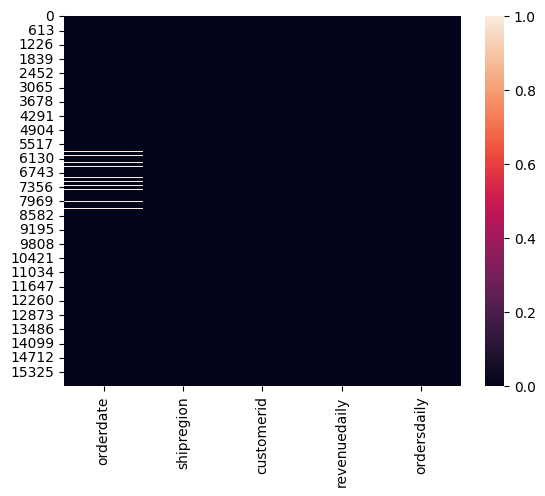

In [5]:
# Задание 3
sns.heatmap(df.isnull())
# Доля пропусков
for i in df.columns:
    print(f'Доля пропусков в колонке {i}: {round(len(df[df[i].isna()])/len(df[i]),2)*100}%')

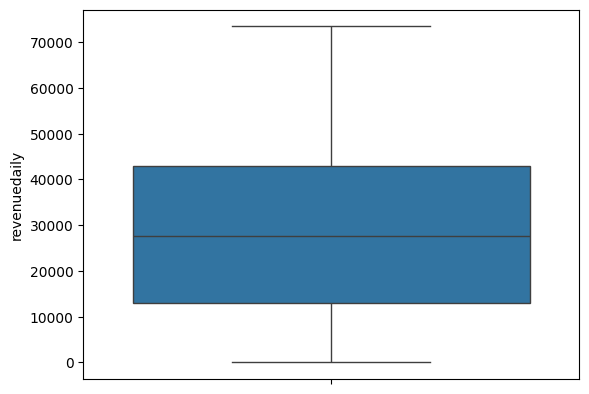

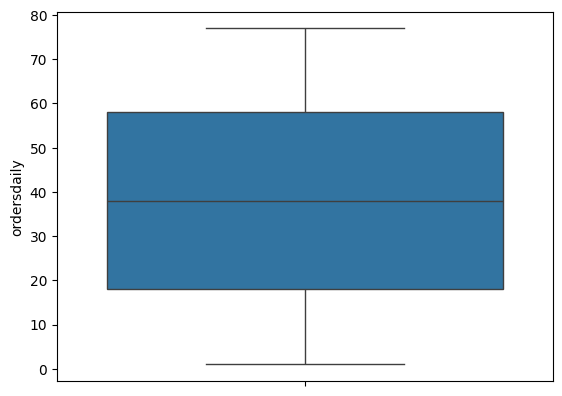

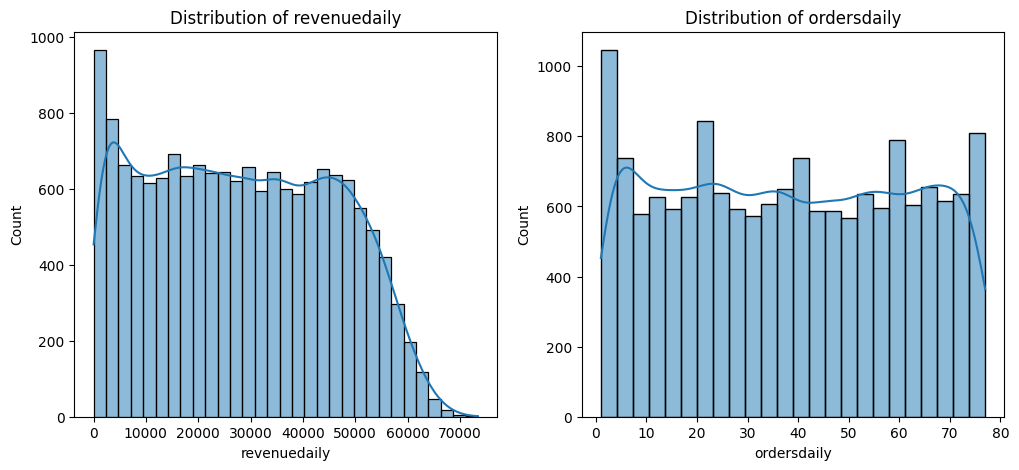

In [6]:
# Задание 4.1
lst = ['revenuedaily', 'ordersdaily']
for i in lst:
    sns.boxplot(df[i])
    plt.show()
# Выбросов не обнаружено

# Задание 4.2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(lst):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# У revenudaily распределение скошено вправо, а у ordersdaily распределение практически равномерное

In [7]:
# Задание 5

df = df.set_index('orderdate')
weekly = df.resample('W').sum()
monthly = df.resample('M').sum()

display(weekly.head(3))
display(monthly.head(3))

C:\Users\Normc\AppData\Local\Temp\ipykernel_20444\2269100552.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample('M').sum()


,shipregion,customerid,revenuedaily,ordersdaily
orderdate,,,,
2012-07-15,Western EuropeNorth AmericaNorth AmericaSouth ...,GREALRICARLONEPFOLKONORTSAROUTRATTCHUNGORANCHS...,526754.21,759
2012-07-22,Western EuropeSouthern EuropeNorth AmericaCent...,QUEDEFOLIGTORTUSAVEALINODTRADHGALEDEASTCDRACDR...,617065.29,845
2012-07-29,Southern EuropeNorthern EuropeNorth AmericaNor...,GROSRAROUTVALONVAFFEBOLIDPERICFRANRCENTCVICTEF...,638658.60,826


,shipregion,customerid,revenuedaily,ordersdaily
orderdate,,,,
2012-07-31,Western EuropeNorth AmericaNorth AmericaSouth ...,GREALRICARLONEPFOLKONORTSAROUTRATTCHUNGORANCHS...,2066219.40,2821
2012-08-31,North AmericaCentral AmericaSouthern EuropeWes...,CHOPSNORTSDUMONGODOSPERICWARTHBOTTMGALEDCACTUK...,3556875.79,4773
2012-09-30,South AmericaNorth AmericaSouthern EuropeSouth...,LACORGREALRICSUSEVESSPECDRANCHANATRLILASBOTTMB...,3440144.98,4711


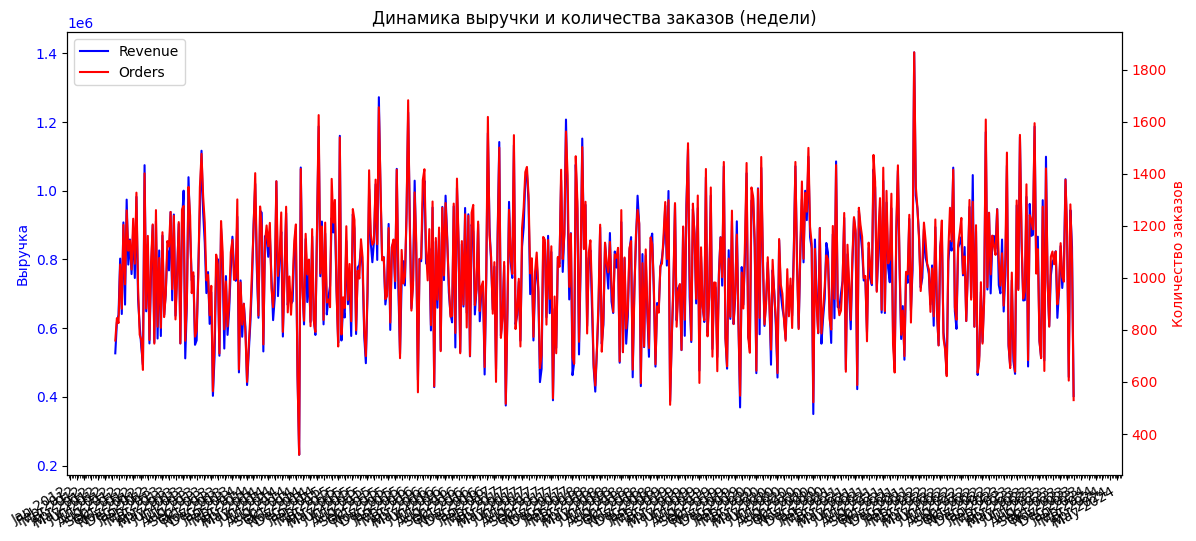

In [8]:
# Задание 6 и 7
# Зона эластичности
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(weekly.index, weekly['revenuedaily'], color='blue', label='Revenue')
ax1.set_ylabel('Выручка', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()
ax2.plot(weekly.index, weekly['ordersdaily'], color='red', label='Orders')
ax2.set_ylabel('Количество заказов', color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.title('Динамика выручки и количества заказов (недели)')
plt.xticks(rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter(r'%b %Y'))
ax1.xaxis.set_minor_locator(mdates.WeekdayLocator())
plt.tight_layout()

fig.autofmt_xdate()
plt.show()